In [15]:
import tensorflow as tf
import matplotlib.pyplot as plt
import os
import time
import numpy as np

from tensorflow.keras.layers import Rescaling
from tensorflow.keras.utils import image_dataset_from_directory
from tensorflow.keras import models, layers, Sequential
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.models import load_model
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

In [27]:
TRAIN_DATA_PATH = os.path.join("./rgb_dataset/train")
VALIDATION_DATA_PATH = os.path.join("./rgb_dataset/val")
TEST_DATA_PATH = os.path.join("./rgb_dataset/test")
EPOCHS = 30
RANDOM_SEED = 42
BATCH_SIZE = 32
IMG_SIZE = (75,75)
CLASSES = [d for d in os.listdir(TRAIN_DATA_PATH) if d != '.DS_Store']

In [28]:
# one hot encoding (categorical lbl mode)
train_dataset = image_dataset_from_directory(
    TRAIN_DATA_PATH,
    seed = RANDOM_SEED,
    image_size=IMG_SIZE,
    color_mode="rgb",
    batch_size=BATCH_SIZE,
    label_mode = "categorical" 
)

val_dataset = image_dataset_from_directory(
    VALIDATION_DATA_PATH,
    seed = RANDOM_SEED,
    image_size=IMG_SIZE,
    color_mode="rgb",
    batch_size=BATCH_SIZE,
    label_mode = "categorical" 
)

test_dataset = image_dataset_from_directory(
    TEST_DATA_PATH,
    image_size=IMG_SIZE,
    color_mode="rgb",
    batch_size=BATCH_SIZE,
    label_mode = "categorical" 
)

Found 18792 files belonging to 9 classes.
Found 4698 files belonging to 9 classes.
Found 2610 files belonging to 9 classes.


In [29]:
# CNN works better with 0-1 px values
layer_normalization = Rescaling(1./255)

train_dataset = train_dataset.map(lambda x, y: (layer_normalization(x), y))
val_dataset = val_dataset.map(lambda x, y: (layer_normalization(x),y))
test_dataset = test_dataset.map(lambda x, y: (layer_normalization(x),y))

In [30]:
data_augmentation = Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

In [33]:
train_counts = {}

for cls in CLASSES:
    cls_folder = os.path.join(TRAIN_DATA_PATH, cls)
    train_counts[cls] = len(os.listdir(cls_folder))

print(train_counts)

{'angry': 2088, 'confused': 2088, 'disgust': 2088, 'fear': 2088, 'happy': 2088, 'neutral': 2088, 'sad': 2088, 'shy': 2088, 'surprise': 2088}


In [34]:
# Calculate class weights for imbalanced dataset
# Create label list manually from folder counts
labels = []

for idx, cls in enumerate(CLASSES):
    count = train_counts[cls]
    labels.extend([idx] * count)

labels = np.array(labels)

class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(labels),
    y=labels
)

class_weights = dict(enumerate(class_weights_array))
print("Class weights:", class_weights)

Class weights: {0: np.float64(1.0), 1: np.float64(1.0), 2: np.float64(1.0), 3: np.float64(1.0), 4: np.float64(1.0), 5: np.float64(1.0), 6: np.float64(1.0), 7: np.float64(1.0), 8: np.float64(1.0)}


In [20]:
model = models.Sequential([
    data_augmentation,
    layers.Conv2D(64, 3, data_format="channels_last", input_shape = (75,75,3)),
    layers.BatchNormalization(),
    layers.Activation('relu'),

    layers.Conv2D(64,3),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPool2D(pool_size=(2,2), strides=2),
    layers.Dropout(0.3),

    layers.Conv2D(32,3),
    layers.BatchNormalization(),
    layers.Activation('relu'),

    layers.Conv2D(32,3),
    layers.BatchNormalization(),
    layers.Activation('relu'),

    layers.Conv2D(32,3),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPool2D(pool_size=(2,2), strides=2),
    layers.Dropout(0.3),

    layers.Flatten(),
    layers.Dense(128),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Dropout(0.3),

    layers.Dense(9),
    layers.Activation('softmax')
])

model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
model.summary()

c:\Users\User\anaconda3\envs\cuda\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_2 (Sequential)       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_7 (Activation)       │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_8 (Activation)       │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_9 (Activation)       │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_10 (Activation)      │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_11 (Activation)      │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [21]:
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

In [39]:
start = time.time()
history = model.fit(
    train_dataset,
    validation_data = val_dataset,
    epochs=EPOCHS,
    callbacks = [early_stop]
)
end = time.time()

print("Training time: ", (end - start)/60)

Epoch 1/30
588/588 ━━━━━━━━━━━━━━━━━━━━ 91s 150ms/step - accuracy: 0.2232 - loss: 2.1436 - val_accuracy: 0.2414 - val_loss: 2.0104
Epoch 2/30
588/588 ━━━━━━━━━━━━━━━━━━━━ 90s 153ms/step - accuracy: 0.2900 - loss: 1.9401 - val_accuracy: 0.2784 - val_loss: 2.0171
Epoch 3/30
588/588 ━━━━━━━━━━━━━━━━━━━━ 89s 151ms/step - accuracy: 0.3238 - loss: 1.8477 - val_accuracy: 0.3374 - val_loss: 1.8291
Epoch 4/30
588/588 ━━━━━━━━━━━━━━━━━━━━ 87s 147ms/step - accuracy: 0.3461 - loss: 1.7890 - val_accuracy: 0.3576 - val_loss: 1.7547
Epoch 5/30
588/588 ━━━━━━━━━━━━━━━━━━━━ 91s 155ms/step - accuracy: 0.3688 - loss: 1.7469 - val_accuracy: 0.3414 - val_loss: 1.8238
Epoch 6/30
588/588 ━━━━━━━━━━━━━━━━━━━━ 89s 151ms/step - accuracy: 0.3838 - loss: 1.7104 - val_accuracy: 0.4006 - val_loss: 1.6675
Epoch 7/30
588/588 ━━━━━━━━━━━━━━━━━━━━ 89s 150ms/step - accuracy: 0.3945 - loss: 1.6809 - val_accuracy: 0.3074 - val_loss: 1.9151
Epoch 8/30
588/588 ━━━━━━━━━━━━━━━━━━━━ 90s 153ms/step - accuracy: 0.4037 - loss: 1

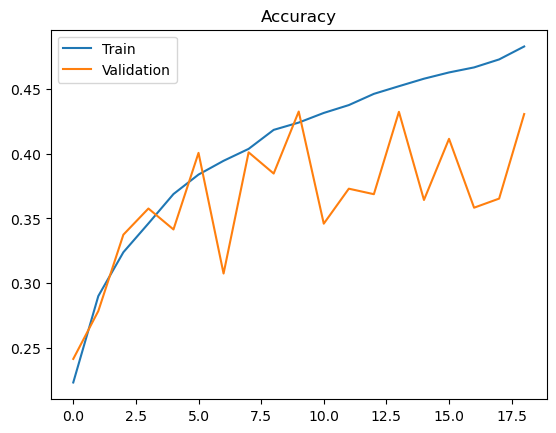

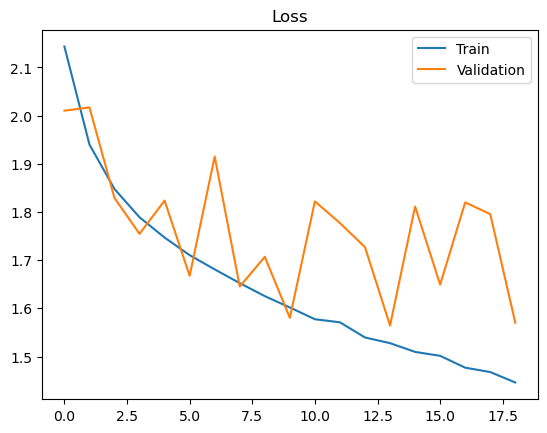

In [ ]:
# plt.plot(history.history['accuracy'])
# plt.plot(history.history['val_accuracy'])
# plt.title("Accuracy")
# plt.legend(['Train','Validation'])
# plt.show()

# plt.plot(history.history['loss'])
# plt.plot(history.history['val_loss'])
# plt.title("Loss")
# plt.legend(['Train','Validation'])
# plt.show()


plt.figure(figsize=(12,5))

# Loss
plt.subplot(1,2,1)
plt.plot(history.history['loss'],)
plt.plot(history.history['val_loss'],)
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Accuracy
plt.subplot(1,2,2)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train','Validation'])

plt.show()

In [42]:
model.save('affectnet_cnn.h5')

In [43]:
model = tf.keras.models.load_model('affectnet_cnn.h5')

In [41]:
test_loss, test_acc = model.evaluate(test_dataset)
print("Test Accuracy: ", test_acc)

82/82 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - accuracy: 0.4517 - loss: 1.5387
Test Accuracy:  0.4517241418361664
